In [4]:
from google.colab import files
uploaded = files.upload()

Saving december-chart-inputs.csv to december-chart-inputs.csv
Saving train-test.csv to train-test.csv
Saving validation.csv to validation.csv
Saving validation-predictions-template.csv to validation-predictions-template.csv


In [5]:
import os
print(os.listdir())

['.config', 'validation-predictions-template.csv', 'validation.csv', 'train-test.csv', 'december-chart-inputs.csv', 'sample_data']


In [6]:
import pandas as pd
import numpy as np

train_test = pd.read_csv('train-test.csv')
validation = pd.read_csv('validation.csv')
predictions_template = pd.read_csv('validation-predictions-template.csv')
december_inputs = pd.read_csv('december-chart-inputs.csv')

print("train_test:", train_test.shape, "-> expect (48000, 14)")
print(train_test.columns.tolist())
print()
print("validation:", validation.shape, "-> expect (12000, 13)")
print(validation.columns.tolist())
print()
print("predictions_template:", predictions_template.shape, "-> expect (12000, 2)")
print(predictions_template.columns.tolist())
print()
print("december_inputs:", december_inputs.shape, "-> expect (31, 7)")
print(december_inputs.columns.tolist())

train_test: (48000, 14) -> expect (48000, 14)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

validation: (12000, 13) -> expect (12000, 13)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

predictions_template: (12000, 2) -> expect (12000, 2)
['load_id', 'predicted_rate']

december_inputs: (31, 7) -> expect (31, 7)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [7]:
print("Missing values in train_test:")
print(train_test.isna().sum())
print()
print("Negative weights in train_test:", (train_test['weight'] < 0).sum())
print("Negative weights in validation:", (validation['weight'] < 0).sum())
print()
print("Missing values in validation:")
print(validation.isna().sum())

Missing values in train_test:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

Negative weights in train_test: 292
Negative weights in validation: 145

Missing values in validation:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


In [8]:
train_test['weight'] = train_test['weight'].abs()
validation['weight'] = validation['weight'].abs()

print("Negative weights left in train_test:", (train_test['weight'] < 0).sum())
print("Negative weights left in validation:", (validation['weight'] < 0).sum())

Negative weights left in train_test: 0
Negative weights left in validation: 0


In [9]:
for col in ['weight', 'market_index']:
    train_test[f'{col}_was_missing'] = train_test[col].isna().astype(int)
    validation[f'{col}_was_missing'] = validation[col].isna().astype(int)

    median_val = train_test[col].median()   # always use TRAIN's median for both
    train_test[col] = train_test[col].fillna(median_val)
    validation[col] = validation[col].fillna(median_val)

print("Remaining missing in train_test:")
print(train_test.isna().sum())
print()
print("Remaining missing in validation:")
print(validation.isna().sum())

Remaining missing in train_test:
load_id                     0
pickup                      0
delivery                    0
pickup_lat                  0
pickup_lon                  0
delivery_lat                0
delivery_lon                0
distance                    0
equipment                   0
weight                      0
date                        0
market_index                0
quote_signal                0
posted_rate                 0
weight_was_missing          0
market_index_was_missing    0
dtype: int64

Remaining missing in validation:
load_id                     0
pickup                      0
delivery                    0
pickup_lat                  0
pickup_lon                  0
delivery_lat                0
delivery_lon                0
distance                    0
equipment                   0
weight                      0
date                        0
market_index                0
quote_signal                0
weight_was_missing          0
market_index_was_mis

In [10]:
rate_per_mile = train_test['posted_rate'] / train_test['distance']
print(rate_per_mile.describe())
print()
print("Top 10 highest rate/mile:")
print(rate_per_mile.sort_values(ascending=False).head(10))

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
dtype: float64

Top 10 highest rate/mile:
22254    14.125294
36609    14.089634
870      13.315576
17070    12.949578
27969    12.879335
23369    12.873327
28012    12.863429
45483    12.816710
1415     12.663774
21968    12.654853
dtype: float64


In [11]:
train_test['date'] = pd.to_datetime(train_test['date'])
validation['date'] = pd.to_datetime(validation['date'])

print("train_test date range:", train_test['date'].min(), "to", train_test['date'].max())
print("validation date range:", validation['date'].min(), "to", validation['date'].max())

train_test date range: 2025-01-01 00:00:00 to 2025-10-31 00:00:00
validation date range: 2025-11-01 00:00:00 to 2025-12-31 00:00:00


In [12]:
validation['date'].dt.to_period('M').value_counts().sort_index()

,count
date,
2025-11,5836
2025-12,6164


feature engineering

In [13]:
for df in [train_test, validation]:
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear

train_test = pd.get_dummies(train_test, columns=['equipment'], prefix='equip')
validation = pd.get_dummies(validation, columns=['equipment'], prefix='equip')

print(train_test.columns.tolist())
print(validation.columns.tolist())

['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate', 'weight_was_missing', 'market_index_was_missing', 'month', 'day_of_week', 'day_of_year', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'date', 'market_index', 'quote_signal', 'weight_was_missing', 'market_index_was_missing', 'month', 'day_of_week', 'day_of_year', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']


In [14]:
split_date = '2025-09-01'

train_df = train_test[train_test['date'] < split_date].copy()
holdout_df = train_test[train_test['date'] >= split_date].copy()

print("train_df:", train_df.shape, train_df['date'].min(), "to", train_df['date'].max())
print("holdout_df:", holdout_df.shape, holdout_df['date'].min(), "to", holdout_df['date'].max())

train_df: (38477, 21) 2025-01-01 00:00:00 to 2025-08-31 00:00:00
holdout_df: (9523, 21) 2025-09-01 00:00:00 to 2025-10-31 00:00:00


In [15]:
pickup_freq = train_df['pickup'].value_counts(normalize=True)
delivery_freq = train_df['delivery'].value_counts(normalize=True)

for df in [train_df, holdout_df, validation]:
    df['pickup_freq'] = df['pickup'].map(pickup_freq).fillna(0)
    df['delivery_freq'] = df['delivery'].map(delivery_freq).fillna(0)

print(train_df[['pickup', 'pickup_freq', 'delivery', 'delivery_freq']].head())

         pickup  pickup_freq      delivery  delivery_freq
0      Richmond     0.024456     Baltimore       0.009590
1      Richmond     0.024456  Philadelphia       0.020246
2  Philadelphia     0.019154     Green Bay       0.013878
3      Hartford     0.023625       Atlanta       0.022897
4        Dallas     0.005900     Nashville       0.022819


In [16]:
feature_cols = [
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance', 'weight', 'market_index', 'quote_signal',
    'weight_was_missing', 'market_index_was_missing',
    'month', 'day_of_week', 'day_of_year',
    'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer',
    'pickup_freq', 'delivery_freq'
]

X_train = train_df[feature_cols]
y_train = train_df['posted_rate']

X_holdout = holdout_df[feature_cols]
y_holdout = holdout_df['posted_rate']

print(X_train.shape, X_holdout.shape)

(38477, 18) (9523, 18)


In [17]:
!pip install lightgbm -q

In [19]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_holdout, y_holdout)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)]
)

preds_holdout = model.predict(X_holdout)

rmse = np.sqrt(mean_squared_error(y_holdout, preds_holdout))
mae = mean_absolute_error(y_holdout, preds_holdout)
mape = mean_absolute_percentage_error(y_holdout, preds_holdout)

print(f"Holdout RMSE: {rmse:.2f}")
print(f"Holdout MAE:  {mae:.2f}")
print(f"Holdout MAPE: {mape:.2%}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1676
[LightGBM] [Info] Number of data points in the train set: 38477, number of used features: 18
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 2369.409512
Training until validation scores don't improve for 30 rounds
[50]	valid_0's rmse: 648.424	valid_0's l2: 420454
[100]	valid_0's rmse: 634.511	valid_0's l2: 402605
Early stopping, best iteration is:
[108]	valid_0's rmse: 634.341	valid_0's l2: 402388
Holdout RMSE: 634.34
Holdout MAE:  123.51
Holdout MAPE: 5.57%


In [21]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression()
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_holdout)

baseline_rmse = np.sqrt(mean_squared_error(y_holdout, baseline_preds))
print(f"Linear baseline RMSE: {baseline_rmse:.2f}  vs  LightGBM RMSE: {rmse:.2f}")

Linear baseline RMSE: 638.26  vs  LightGBM RMSE: 634.34


In [22]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

                     feature  importance
4                   distance         822
5                     weight         358
6               market_index         353
7               quote_signal         340
12               day_of_year         318
13             equip_Dry Van         222
16               pickup_freq         148
0                 pickup_lat         145
2               delivery_lat         132
15              equip_Reefer         110
3               delivery_lon          96
1                 pickup_lon          87
17             delivery_freq          59
11               day_of_week          33
10                     month          15
14             equip_Flatbed           2
9   market_index_was_missing           0
8         weight_was_missing           0


In [23]:
holdout_df['predicted'] = preds_holdout
holdout_df['abs_error'] = (holdout_df['posted_rate'] - holdout_df['predicted']).abs()
print(holdout_df.sort_values('abs_error', ascending=False)[['load_id', 'posted_rate', 'predicted', 'abs_error', 'distance']].head(10))

         load_id  posted_rate    predicted     abs_error  distance
40096  TR-040097     20132.37  3897.701154  16234.668846    1760.3
40171  TR-040172     20361.89  4549.981989  15811.908011    2283.4
43539  TR-043540     17514.11  3742.412108  13771.697892    1893.0
46213  TR-046214     17893.17  4160.329294  13732.840706    2023.4
47298  TR-047299     19110.30  6073.138466  13037.161534    2979.1
40322  TR-040323     14949.25  3207.311609  11741.938391    1639.9
46516  TR-046517     14784.38  3604.557782  11179.822218    1684.3
42881  TR-042882     13503.63  2958.135230  10545.494770    1460.5
42149  TR-042150     13026.22  2836.986715  10189.233285    1415.5
44267  TR-044268     14425.42  4515.890853   9909.529147    2492.6


In [24]:
# Re-encode using full train_test (not just train_df)
pickup_freq_full = train_test['pickup'].value_counts(normalize=True)
delivery_freq_full = train_test['delivery'].value_counts(normalize=True)

train_test['pickup_freq'] = train_test['pickup'].map(pickup_freq_full).fillna(0)
train_test['delivery_freq'] = train_test['delivery'].map(delivery_freq_full).fillna(0)
validation['pickup_freq'] = validation['pickup'].map(pickup_freq_full).fillna(0)
validation['delivery_freq'] = validation['delivery'].map(delivery_freq_full).fillna(0)

X_full = train_test[feature_cols]
y_full = train_test['posted_rate']

final_model = lgb.LGBMRegressor(
    n_estimators=model.best_iteration_,   # use the same number of trees early stopping found
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)
final_model.fit(X_full, y_full)

print("Final model trained on", X_full.shape[0], "rows")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1672
[LightGBM] [Info] Number of data points in the train set: 48000, number of used features: 18
[LightGBM] [Info] Start training from score 2373.980682
Final model trained on 48000 rows


In [25]:
X_validation = validation[feature_cols]
validation['predicted_rate'] = final_model.predict(X_validation)

# Sanity check: no non-positive predictions allowed by score.py
print("Any non-positive predictions?", (validation['predicted_rate'] <= 0).sum())

output = validation[['load_id', 'predicted_rate']]
output.to_csv('validation_predictions.csv', index=False)
print(output.shape)
output.head()

Any non-positive predictions? 0
(12000, 2)


,load_id,predicted_rate
0,TE-000001,878.461691
1,TE-000002,5038.213237
2,TE-000003,5898.855221
3,TE-000004,4273.624007
4,TE-000005,1856.853182


In [26]:
december_inputs['date'] = pd.to_datetime(december_inputs['date'])
december_inputs['weight'] = december_inputs['weight'].abs()

# Add missing flags (there shouldn't be any missing values here, but keep pipeline consistent)
december_inputs['weight_was_missing'] = 0
december_inputs['market_index_was_missing'] = 0

december_inputs['month'] = december_inputs['date'].dt.month
december_inputs['day_of_week'] = december_inputs['date'].dt.dayofweek
december_inputs['day_of_year'] = december_inputs['date'].dt.dayofyear

december_inputs = pd.get_dummies(december_inputs, columns=['equipment'], prefix='equip')
for col in ['equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']:
    if col not in december_inputs.columns:
        december_inputs[col] = False

# December file has no market_index/quote_signal or lat/lon columns —
# it's a single fixed lane, so use that lane's known values from train_test
lexington_fw = train_test[(train_test['pickup'] == 'Lexington') & (train_test['delivery'] == 'Fort Wayne')]
print("Historical Lexington->Fort Wayne rows found:", len(lexington_fw))

Historical Lexington->Fort Wayne rows found: 32


In [27]:
lexington_fw = train_test[(train_test['pickup'] == 'Lexington') & (train_test['delivery'] == 'Fort Wayne')]
print("Historical Lexington->Fort Wayne rows found:", len(lexington_fw))

if len(lexington_fw) > 0:
    # Use this lane's actual historical values
    fill_pickup_lat = lexington_fw['pickup_lat'].mean()
    fill_pickup_lon = lexington_fw['pickup_lon'].mean()
    fill_delivery_lat = lexington_fw['delivery_lat'].mean()
    fill_delivery_lon = lexington_fw['delivery_lon'].mean()
    fill_market_index = lexington_fw['market_index'].mean()
    fill_quote_signal = lexington_fw['quote_signal'].mean()
    print("Using this lane's own historical averages.")
else:
    # Fall back to city-level averages from any route touching these cities, else global medians
    pickup_rows = train_test[train_test['pickup'] == 'Lexington']
    delivery_rows = train_test[train_test['delivery'] == 'Fort Wayne']
    fill_pickup_lat = pickup_rows['pickup_lat'].mean() if len(pickup_rows) else train_test['pickup_lat'].median()
    fill_pickup_lon = pickup_rows['pickup_lon'].mean() if len(pickup_rows) else train_test['pickup_lon'].median()
    fill_delivery_lat = delivery_rows['delivery_lat'].mean() if len(delivery_rows) else train_test['delivery_lat'].median()
    fill_delivery_lon = delivery_rows['delivery_lon'].mean() if len(delivery_rows) else train_test['delivery_lon'].median()
    fill_market_index = train_test['market_index'].median()
    fill_quote_signal = train_test['quote_signal'].median()
    print("Exact lane not found in training data — used city-level fallback / global medians instead.")

print("pickup_lat:", fill_pickup_lat, "pickup_lon:", fill_pickup_lon)
print("delivery_lat:", fill_delivery_lat, "delivery_lon:", fill_delivery_lon)
print("market_index:", fill_market_index, "quote_signal:", fill_quote_signal)

december_inputs['pickup_lat'] = fill_pickup_lat
december_inputs['pickup_lon'] = fill_pickup_lon
december_inputs['delivery_lat'] = fill_delivery_lat
december_inputs['delivery_lon'] = fill_delivery_lon
december_inputs['market_index'] = fill_market_index
december_inputs['quote_signal'] = fill_quote_signal
december_inputs['pickup_freq'] = pickup_freq_full.get('Lexington', 0)
december_inputs['delivery_freq'] = delivery_freq_full.get('Fort Wayne', 0)

X_december = december_inputs[feature_cols]
december_inputs['predicted_rate'] = final_model.predict(X_december)

print(december_inputs[['pickup', 'delivery', 'date', 'predicted_rate']])

Historical Lexington->Fort Wayne rows found: 32
Using this lane's own historical averages.
pickup_lat: 36.99152 pickup_lon: -84.99876
delivery_lat: 41.31561 delivery_lon: -85.36206
market_index: 1.0414715625 quote_signal: 2.0106725
       pickup    delivery       date  predicted_rate
0   Lexington  Fort Wayne 2025-12-01      875.129403
1   Lexington  Fort Wayne 2025-12-02      875.129403
2   Lexington  Fort Wayne 2025-12-03      875.129403
3   Lexington  Fort Wayne 2025-12-04      875.129403
4   Lexington  Fort Wayne 2025-12-05      875.129403
5   Lexington  Fort Wayne 2025-12-06      875.129403
6   Lexington  Fort Wayne 2025-12-07      875.129403
7   Lexington  Fort Wayne 2025-12-08      875.129403
8   Lexington  Fort Wayne 2025-12-09      875.129403
9   Lexington  Fort Wayne 2025-12-10      875.129403
10  Lexington  Fort Wayne 2025-12-11      875.129403
11  Lexington  Fort Wayne 2025-12-12      875.129403
12  Lexington  Fort Wayne 2025-12-13      875.129403
13  Lexington  Fort Wayne 

In [28]:
print(december_inputs[['date', 'month', 'day_of_week', 'day_of_year']])

         date  month  day_of_week  day_of_year
0  2025-12-01     12            0          335
1  2025-12-02     12            1          336
2  2025-12-03     12            2          337
3  2025-12-04     12            3          338
4  2025-12-05     12            4          339
5  2025-12-06     12            5          340
6  2025-12-07     12            6          341
7  2025-12-08     12            0          342
8  2025-12-09     12            1          343
9  2025-12-10     12            2          344
10 2025-12-11     12            3          345
11 2025-12-12     12            4          346
12 2025-12-13     12            5          347
13 2025-12-14     12            6          348
14 2025-12-15     12            0          349
15 2025-12-16     12            1          350
16 2025-12-17     12            2          351
17 2025-12-18     12            3          352
18 2025-12-19     12            4          353
19 2025-12-20     12            5          354
20 2025-12-21

In [30]:
december_inputs['equipment'] = 'Dry Van'  # fixed value per the assessment spec

december_output = december_inputs[['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']].copy()
december_output.to_csv('december-chart-inputs.csv', index=False)
print(december_output)

       pickup    delivery  distance equipment  weight       date  \
0   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-13   
13  Lexington  Fort Wayne       360   Dry Van   

In [31]:
%%writefile score.py
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


EXPECTED_ROWS = 12_000
EXPECTED_IDS = {f"TE-{index:06d}" for index in range(1, EXPECTED_ROWS + 1)}
DECEMBER_DATES = pd.date_range("2025-12-01", "2025-12-31", freq="D")
FIXED_PICKUP = "Lexington"
FIXED_DELIVERY = "Fort Wayne"
FIXED_DISTANCE = 360.0
FIXED_EQUIPMENT = "Dry Van"
FIXED_WEIGHT = 32_000.0


def fail(message: str) -> None:
    raise SystemExit(f"ERROR: {message}")


def read_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.is_file():
        fail(f"{label} file not found: {path}")
    try:
        return pd.read_csv(path)
    except Exception as exc:
        fail(f"could not read {label}: {exc}")


def numeric_series(frame: pd.DataFrame, column: str, label: str) -> pd.Series:
    values = pd.to_numeric(frame[column], errors="coerce")
    if values.isna().any() or not np.isfinite(values).all():
        fail(f"{label} contains invalid {column} values")
    return values.astype(float)


def validate_predictions(predictions: pd.DataFrame) -> None:
    if list(predictions.columns) != ["load_id", "predicted_rate"]:
        fail("predictions must contain exactly two columns in this order: load_id,predicted_rate")
    if len(predictions) != EXPECTED_ROWS:
        fail(f"predictions must contain exactly {EXPECTED_ROWS:,} rows")
    if predictions["load_id"].isna().any() or predictions["load_id"].duplicated().any():
        fail("predictions contains missing or duplicate load_id values")

    submitted_ids = set(predictions["load_id"].astype(str))
    missing = EXPECTED_IDS - submitted_ids
    extra = submitted_ids - EXPECTED_IDS
    if missing or extra:
        fail(
            "prediction IDs do not match the validation set "
            f"(missing={len(missing)}, extra={len(extra)})"
        )

    predicted_rate = numeric_series(predictions, "predicted_rate", "predictions")
    if (predicted_rate <= 0).any():
        fail("predictions contains non-positive predicted_rate values")


def validate_december(frame: pd.DataFrame) -> pd.DataFrame:
    columns = ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]
    if list(frame.columns) != columns:
        fail("December predictions must keep the original seven columns and column order")

    result = frame.copy()
    result["date"] = pd.to_datetime(result["date"], errors="coerce")
    if result["date"].isna().any():
        fail("December predictions contains invalid dates")
    result["distance"] = numeric_series(result, "distance", "December predictions")
    result["weight"] = numeric_series(result, "weight", "December predictions")
    result["predicted_rate"] = numeric_series(result, "predicted_rate", "December predictions")

    if result["date"].duplicated().any():
        fail("December predictions contains duplicate dates")
    if len(result) != 31 or set(result["date"]) != set(DECEMBER_DATES):
        fail("December predictions must contain one row for every day from 2025-12-01 to 2025-12-31")
    if not result["pickup"].eq(FIXED_PICKUP).all():
        fail(f"December pickup must be {FIXED_PICKUP} for all rows")
    if not result["delivery"].eq(FIXED_DELIVERY).all():
        fail(f"December delivery must be {FIXED_DELIVERY} for all rows")
    if not np.isclose(result["distance"], FIXED_DISTANCE).all():
        fail(f"December distance must be {FIXED_DISTANCE:g} for all rows")
    if not result["equipment"].eq(FIXED_EQUIPMENT).all():
        fail(f"December equipment must be {FIXED_EQUIPMENT} for all rows")
    if not np.isclose(result["weight"], FIXED_WEIGHT).all():
        fail(f"December weight must be {FIXED_WEIGHT:g} for all rows")
    if (result["predicted_rate"] <= 0).any():
        fail("December predicted_rate values must be positive")
    return result.sort_values("date")


def save_december_chart(december: pd.DataFrame, output: Path) -> None:
    figure, axis = plt.subplots(figsize=(10.8, 4.8), dpi=180)
    color = "#064A56"
    axis.plot(
        december["date"],
        december["predicted_rate"],
        color=color,
        linewidth=2.6,
        marker="o",
        markersize=3.2,
    )
    floor = float(december["predicted_rate"].min())
    axis.fill_between(
        december["date"],
        december["predicted_rate"],
        floor - max(10.0, floor * 0.02),
        color=color,
        alpha=0.08,
    )
    axis.set_title("Candidate: December 2025 Predicted Load Rate", loc="left", fontsize=15, fontweight="bold", pad=12)
    axis.set_ylabel("Predicted rate ($)")
    axis.grid(axis="y", color="#D9E2E4", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)
    axis.spines[["left", "bottom"]].set_color("#9DAFB3")
    axis.tick_params(axis="x", rotation=35)
    axis.text(
        0,
        -0.40,
        "Fixed inputs: Lexington to Fort Wayne | 360 miles | Dry Van | 32,000 lb | only date changes",
        transform=axis.transAxes,
        fontsize=9.5,
        color="#455A60",
    )
    figure.tight_layout(rect=(0, 0.12, 1, 1))
    figure.savefig(output, bbox_inches="tight")
    plt.close(figure)


def main() -> None:
    parser = argparse.ArgumentParser(
        description="Validate candidate output files and generate the fixed December chart."
    )
    parser.add_argument("--predictions", required=True, help="CSV with load_id,predicted_rate")
    parser.add_argument(
        "--december-predictions",
        required=True,
        help="Completed data/december_chart_inputs.csv",
    )
    parser.add_argument("--output-dir", default="scorer_results")
    args = parser.parse_args()

    validate_predictions(read_csv(Path(args.predictions), "predictions"))
    december = validate_december(read_csv(Path(args.december_predictions), "December predictions"))
    output = Path(args.output_dir)
    output.mkdir(parents=True, exist_ok=True)
    chart = output / "candidate_december.png"
    save_december_chart(december, chart)

    print(f"Validated {EXPECTED_ROWS:,} final predictions.")
    print("Validated 31 fixed December predictions.")
    print(f"Created chart: {chart}")
    print("Final validation metrics are calculated by Spotter after submission.")


if __name__ == "__main__":
    main()

Writing score.py


In [32]:
!python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


In [33]:
from google.colab import files

files.download('validation_predictions.csv')
files.download('scorer_results/candidate_december.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

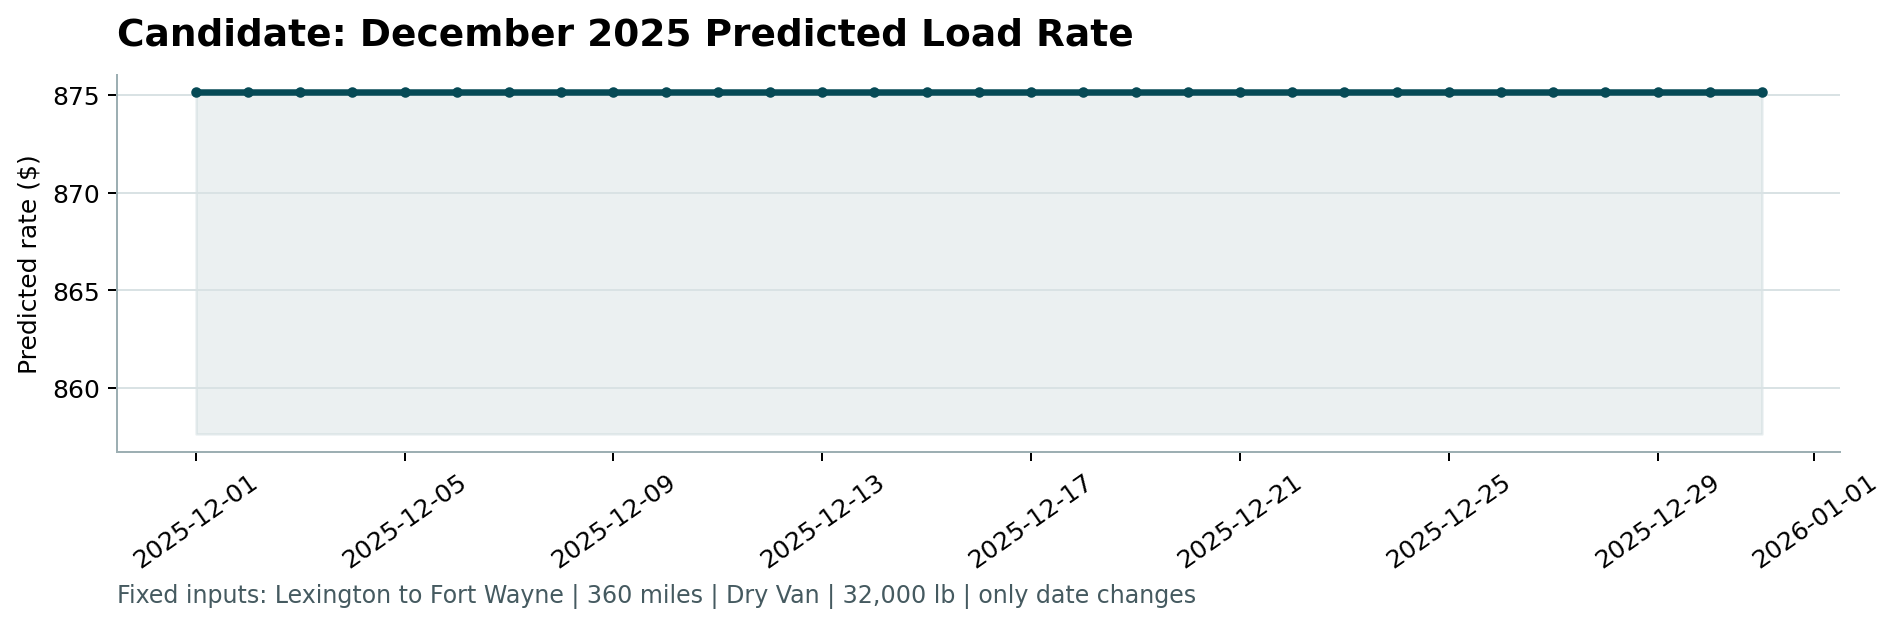

In [34]:
from IPython.display import Image
Image('scorer_results/candidate_december.png')